# 03 — Modelo Tabular MLP
### GalaxyNet — Classificador Morfológico de Galáxias

Rede Neural Multi-Camadas (MLP) usando apenas as 15 features fotométricas e espectroscópicas tabulares. Arquitetura: Dense(256) → BN → Dropout → Dense(128) → BN → Dropout → Dense(64) → BN → Dropout → Softmax(3).

Desbalanceamento de classes tratado com `class_weight='balanced'`.

In [1]:
import sys
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

# Localiza src/ de forma robusta
def _find_src_dir():
    current = os.path.abspath(os.getcwd())
    for _ in range(5):
        candidate = os.path.join(current, 'src')
        if os.path.isdir(candidate):
            return candidate
        current = os.path.dirname(current)
    raise RuntimeError("Diretório src/ não encontrado.")

src_path = _find_src_dir()
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical

from preprocessing import load_preprocessed_tabular, TABULAR_FEATURES
from models import create_mlp_model
from evaluation import evaluate_galaxy_classifier

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Caminhos
_project_root = os.path.dirname(src_path)
PROCESSED_DIR = os.path.join(_project_root, 'data', 'processed')
MODELS_DIR    = os.path.join(_project_root, 'models')
REPORTS_DIR   = os.path.join(_project_root, 'reports', 'figures')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

print(f"TensorFlow    : {tf.__version__}")
print(f"PROCESSED_DIR : {PROCESSED_DIR}")
print(f"MODELS_DIR    : {MODELS_DIR}")
print(f"Features      : {len(TABULAR_FEATURES)}")

I0000 00:00:1776218224.872999   12165 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776218224.939055   12165 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776218227.203535   12165 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow    : 2.21.0
PROCESSED_DIR : /home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed
MODELS_DIR    : /home/luciano/Documentos/GalaxyNet/galaxy_classification/models
Features      : 15


---
## 1. Carregamento dos Dados Pré-processados

In [2]:
X_raw, y_labels, objids, _ = load_preprocessed_tabular(PROCESSED_DIR)

print(f"\nX_raw    : {X_raw.shape}  dtype={X_raw.dtype}")
print(f"y_labels : {y_labels.shape}   classes={np.unique(y_labels)}")
print(f"objids   : {objids.shape}")

print("\nDistribuição de classes:")
unique, counts = np.unique(y_labels, return_counts=True)
for cls, n in zip(unique, counts):
    print(f"  {cls:<12}: {n:>4} ({100*n/len(y_labels):.1f}%)")

Carregado de '/home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed':
  X_tabular : (9054, 15)
  y_labels  : 9054 rótulos
  objids    : 9054 IDs

X_raw    : (9054, 15)  dtype=float32
y_labels : (9054,)   classes=['Elliptical' 'Irregular' 'Spiral']
objids   : (9054,)

Distribuição de classes:
  Elliptical  : 7595 (83.9%)
  Irregular   :  261 (2.9%)
  Spiral      : 1198 (13.2%)


---
## 2. Encoding de Labels e Split Train/Val/Test

- `LabelEncoder` converte strings → inteiros
- `to_categorical` converte inteiros → one-hot
- Split estratificado: **70% train / 15% val / 15% test**

In [3]:
# Encode string labels → integers → one-hot
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
y_one_hot = to_categorical(y_encoded)

num_classes = y_one_hot.shape[1]
print(f"Classes: {list(label_encoder.classes_)} → {list(range(num_classes))}")
print(f"Shape one-hot: {y_one_hot.shape}")

# Split estratificado: 70% train, 15% val, 15% test  (sobre dados BRUTOS)
X_train, X_temp, y_train, y_temp, objids_train, objids_temp = train_test_split(
    X_raw, y_one_hot, objids,
    test_size=0.30, random_state=SEED, stratify=y_encoded
)

# Separar temp em val (50%) e test (50%) → cada um fica com 15% do total
y_temp_encoded = np.argmax(y_temp, axis=1)
_, temp_counts = np.unique(y_temp_encoded, return_counts=True)
use_stratify = temp_counts.min() >= 2

X_val, X_test, y_val, y_test, objids_val, objids_test = train_test_split(
    X_temp, y_temp, objids_temp,
    test_size=0.50, random_state=SEED,
    stratify=y_temp_encoded if use_stratify else None
)

if not use_stratify:
    print("⚠ Classes minoritárias com <2 amostras no temp — segundo split sem stratify")

print(f"\nTrain : {X_train.shape[0]} amostras ({100*X_train.shape[0]/len(X_raw):.0f}%)")
print(f"Val   : {X_val.shape[0]} amostras ({100*X_val.shape[0]/len(X_raw):.0f}%)")
print(f"Test  : {X_test.shape[0]} amostras ({100*X_test.shape[0]/len(X_raw):.0f}%)")

for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    labels = label_encoder.inverse_transform(np.argmax(y_split, axis=1))
    unique, counts = np.unique(labels, return_counts=True)
    dist = ', '.join(f"{c}:{n}" for c, n in zip(unique, counts))
    print(f"  {name}: {dist}")

Classes: ['Elliptical', 'Irregular', 'Spiral'] → [0, 1, 2]
Shape one-hot: (9054, 3)

Train : 6337 amostras (70%)
Val   : 1358 amostras (15%)
Test  : 1359 amostras (15%)
  Train: Elliptical:5316, Irregular:183, Spiral:838
  Val: Elliptical:1139, Irregular:39, Spiral:180
  Test: Elliptical:1140, Irregular:39, Spiral:180


---
## 3. Class Weights para Desbalanceamento

Com apenas 4 galáxias Irregular e 17 Spiral contra 135 Elliptical, usamos `class_weight='balanced'` para penalizar erros nas classes minoritárias proporcionalmente à sua escassez.

---
## 2.5. Escalonamento pós-split (StandardScaler ajustado apenas no treino)

In [4]:
from sklearn.preprocessing import StandardScaler

# Fit APENAS no treino para evitar vazamento de dados para val/test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# Salvar scaler em models/ para uso no notebook 05 (híbrido)
import pickle
scaler_path = os.path.join(MODELS_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"Scaler salvo em: {scaler_path}")
print(f"\nVerificação (X_train deve ter média ≈ 0, std ≈ 1):")
check = pd.DataFrame(X_train, columns=TABULAR_FEATURES)
print(check.agg(['mean', 'std']).round(4).to_string())

Scaler salvo em: /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/scaler.pkl

Verificação (X_train deve ter média ≈ 0, std ≈ 1):
           u       g       r       i       z     u_g     g_r     r_i     i_z  redshift  velDisp  concentration  deVAB_r  expAB_r  fracDeV_r
mean  0.0000 -0.0000  0.0000  0.0000 -0.0000 -0.0000  0.0000  0.0000 -0.0000    0.0000  -0.0000         0.0000  -0.0000  -0.0000    -0.0000
std   1.0001  1.0001  1.0001  1.0001  1.0001  1.0001  1.0001  1.0001  1.0001    1.0001   1.0001         1.0001   1.0001   1.0001     1.0001


In [5]:
# Calcular class weights balanceados a partir do conjunto de treino
y_train_integers = np.argmax(y_train, axis=1)
class_weights_array = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers
)
class_weight_dict = dict(enumerate(class_weights_array))

print("Class weights (balanced):")
for idx, weight in class_weight_dict.items():
    cls_name = label_encoder.inverse_transform([idx])[0]
    n_train = (y_train_integers == idx).sum()
    print(f"  {cls_name:<12} (idx={idx}): weight={weight:.3f}  (n_train={n_train})")

Class weights (balanced):
  Elliptical   (idx=0): weight=0.397  (n_train=5316)
  Irregular    (idx=1): weight=11.543  (n_train=183)
  Spiral       (idx=2): weight=2.521  (n_train=838)


---
## 4. Criação do Modelo MLP

In [6]:
input_shape = X_train.shape[1]
mlp_model = create_mlp_model(input_shape, num_classes)
mlp_model.summary()

E0000 00:00:1776218244.571637   12165 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776218244.573102   12360 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776218244.600238   12165 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,235 (184.51 KB)

 Trainable params: 46,339 (181.01 KB)

 Non-trainable params: 896 (3.50 KB)

---
## 5. Treinamento

- **EarlyStopping**: para o treino se `val_loss` não melhorar por 10 épocas; restaura os melhores pesos
- **ReduceLROnPlateau**: reduz o learning rate pela metade se `val_loss` estagnar por 5 épocas

In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-7, verbose=1
    ),
]

history = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)

print(f"\nTreinamento finalizado em {len(history.history['loss'])} épocas.")

Epoch 1/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6137 - loss: 1.0146 - val_accuracy: 0.7342 - val_loss: 0.7413 - learning_rate: 0.0010
Epoch 2/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7309 - loss: 0.8039 - val_accuracy: 0.7622 - val_loss: 0.6369 - learning_rate: 0.0010
Epoch 3/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7567 - loss: 0.7158 - val_accuracy: 0.7813 - val_loss: 0.5637 - learning_rate: 0.0010
Epoch 4/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7713 - loss: 0.6820 - val_accuracy: 0.7482 - val_loss: 0.6348 - learning_rate: 0.0010
Epoch 5/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7808 - loss: 0.6500 - val_accuracy: 0.8012 - val_loss: 0.5150 - learning_rate: 0.0010
Epoch 6/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7896 - loss: 0.6488 - val_accuracy: 0.7931 - val_loss: 0.5282 - learning_rate: 0.0010
Epoch 7/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7996 - loss: 0.

199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8667 - loss: 0.4014 - val_accuracy: 0.8439 - val_loss: 0.4120 - learning_rate: 2.5000e-04
Epoch 42/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8679 - loss: 0.3884 - val_accuracy: 0.8476 - val_loss: 0.3966 - learning_rate: 1.2500e-04
Epoch 43/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8744 - loss: 0.3853 - val_accuracy: 0.8490 - val_loss: 0.3874 - learning_rate: 1.2500e-04
Epoch 44/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8659 - loss: 0.3813 - val_accuracy: 0.8483 - val_loss: 0.3810 - learning_rate: 1.2500e-04
Epoch 45/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8763 - loss: 0.3697 - val_accuracy: 0.8527 - val_loss: 0.3745 - learning_rate: 1.2500e-04
Epoch 46/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8750 - loss: 0.3801 - val_accuracy: 0.8579 - val_loss: 0.3731 - learning_rate: 1.2500e-04
Epoch 47/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy:

---
## 6. Curvas de Treinamento (Loss e Accuracy)

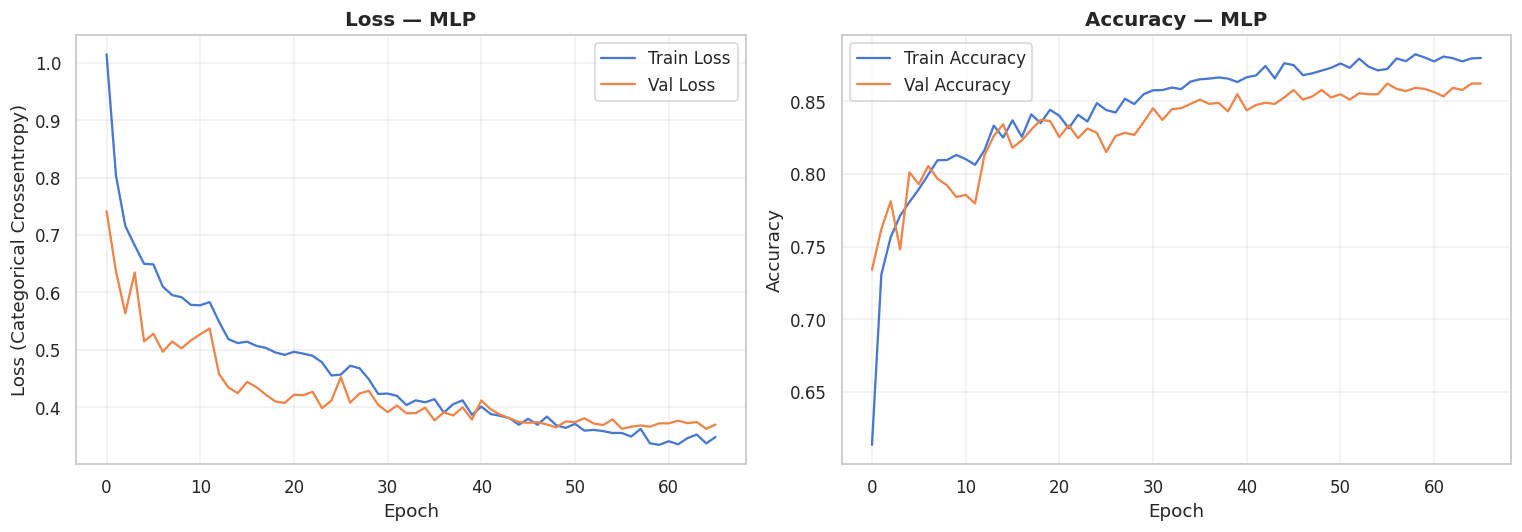

Figura salva: fig16_mlp_training_curves.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss — MLP', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Categorical Crossentropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy — MLP', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig16_mlp_training_curves.png'),
            bbox_inches='tight')
plt.show()
print('Figura salva: fig16_mlp_training_curves.png')

---
## 7. Avaliação no Conjunto de Teste

Métricas: Classification Report, Confusion Matrix, Completeness (Recall) e Reliability (Precision) por classe — métricas padrão em astronomia para avaliação de classificadores de surveys.

MLP Test Loss: 0.3590, Test Accuracy: 0.8646

--- Evaluation for MLP Model ---

Classification Report:
              precision    recall  f1-score   support

  Elliptical       0.99      0.90      0.94      1140
   Irregular       0.21      0.56      0.31        39
      Spiral       0.60      0.71      0.65       180

    accuracy                           0.86      1359
   macro avg       0.60      0.72      0.63      1359
weighted avg       0.91      0.86      0.88      1359


Confusion matrix salva em: /home/luciano/Documentos/GalaxyNet/galaxy_classification/reports/figures/fig17_mlp_confusion_matrix.png


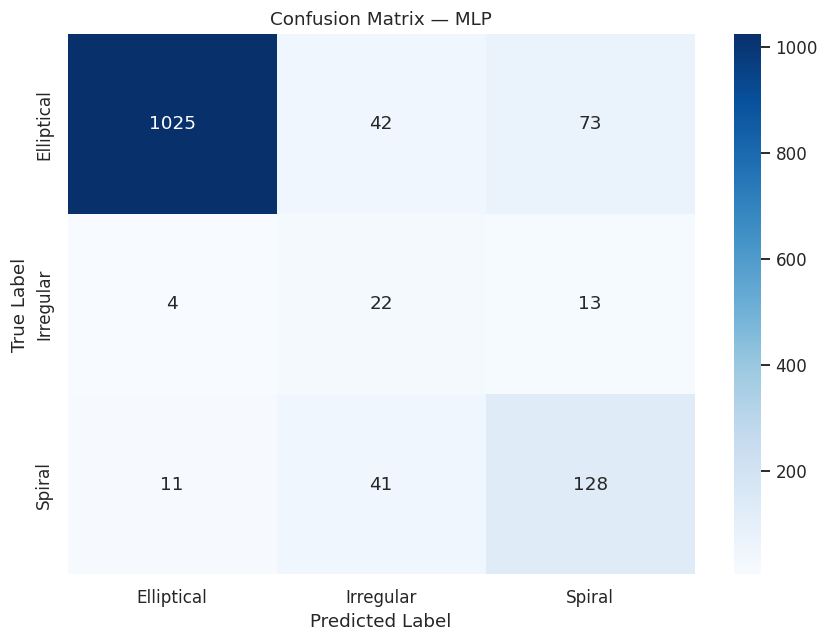


Scientific Metrics (Completeness and Reliability per Class):
     Class  N_True Completeness (Recall) Reliability (Precision)
Elliptical    1140                 0.899                   0.986
 Irregular      39                 0.564                   0.210
    Spiral     180                 0.711                   0.598


In [9]:
# Avaliação completa no conjunto de teste
loss, accuracy = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"MLP Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

eval_results = evaluate_galaxy_classifier(
    model=mlp_model,
    X_test_data=X_test,
    y_test_one_hot=y_test,
    label_encoder=label_encoder,
    model_type='MLP',
    save_dir=REPORTS_DIR,
)

---
## 8. Salvar Modelo e LabelEncoder

In [10]:
# Salvar modelo treinado
model_path = os.path.join(MODELS_DIR, 'mlp_galaxy_classifier.h5')
mlp_model.save(model_path)
print(f"Modelo salvo em: {model_path}")

# Salvar LabelEncoder para reutilização nos notebooks 04 e 05
le_path = os.path.join(MODELS_DIR, 'label_encoder.pkl')
with open(le_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"LabelEncoder salvo em: {le_path}")

# Salvar dados de teste para comparação posterior entre modelos
test_artifacts = {
    'X_test': X_test,
    'y_test': y_test,
    'objids_test': objids_test,
}
test_path = os.path.join(MODELS_DIR, 'mlp_test_data.pkl')
with open(test_path, 'wb') as f:
    pickle.dump(test_artifacts, f)
print(f"Dados de teste salvos em: {test_path}")

Modelo salvo em: /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/mlp_galaxy_classifier.h5
LabelEncoder salvo em: /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/label_encoder.pkl
Dados de teste salvos em: /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/mlp_test_data.pkl


---
## 9. Resumo

In [11]:
print("=" * 55)
print("RESUMO — MODELO MLP TABULAR")
print("=" * 55)
print(f"Features de entrada  : {input_shape}")
print(f"Classes              : {list(label_encoder.classes_)}")
print(f"Amostras (train/val/test): {X_train.shape[0]}/{X_val.shape[0]}/{X_test.shape[0]}")
print(f"Épocas treinadas     : {len(history.history['loss'])}")
print(f"Test Loss            : {loss:.4f}")
print(f"Test Accuracy        : {accuracy:.4f}")
print()
print("Métricas Científicas:")
print(eval_results['scientific_metrics'].to_string(index=False))
print()
print("Artefatos salvos:")
print(f"  1. {model_path}")
print(f"  2. {le_path}")
print(f"  3. reports/figures/fig16_mlp_training_curves.png")
print(f"  4. reports/figures/fig17_mlp_confusion_matrix.png")

RESUMO — MODELO MLP TABULAR
Features de entrada  : 15
Classes              : ['Elliptical', 'Irregular', 'Spiral']
Amostras (train/val/test): 6337/1358/1359
Épocas treinadas     : 46
Test Loss            : 0.3590
Test Accuracy        : 0.8646

Métricas Científicas:
     Class  N_True Completeness (Recall) Reliability (Precision)
Elliptical    1140                 0.899                   0.986
 Irregular      39                 0.564                   0.210
    Spiral     180                 0.711                   0.598

Artefatos salvos:
  1. /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/mlp_galaxy_classifier.h5
  2. /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/label_encoder.pkl
  3. reports/figures/fig16_mlp_training_curves.png
  4. reports/figures/fig17_mlp_confusion_matrix.png
